En este ejercicio se construye numéricamente un **Gaussian Orthogonal Ensemble (GOE)** con \(M=100\) realizaciones para matrices de dimensiones \(N=5,\ 20,\ 100\). Para cada ensemble se calculan los autovalores de las matrices y se compara su distribución la **ley del semicírculo de Wigner**.

El objetivo es observar cómo, al aumentar la dimensión \(N\), la densidad espectral del GOE converge hacia la distribución límite predicha por la teoría de matrices aleatorias.


In [33]:
import numpy as np 
import matplotlib.pyplot as plt

Creamos una función que genere GOE, matrices reales y simétricas de nxn elementos, es decir que H = H\^{T}
sus entradas tendran una distribucion normal con media 0 y desviasión estándar 1
Dentro de la misma función tendrá su matriz simétrica construida desde la matriz origina


In [34]:
def gerenar_goe(N):
    A = np.random.normal(0,1, size = (N,N))
    return (A + A.T) / np.sqrt(2)

Vamos a generar los autovalores, creamos una lista vacía, en un for con rango M, generamos M matrices con NxN, y calculamos sus autovalores, las metemos a la lista, , usamos .extend , despues hacemos una matriz con los autovalores y lo del final es un calculo, tal cual, los autovalores- media de los autovalores / la desviación estándar

In [35]:
def obtención_autovalores(M,N):
    autovalores = []
    for _ in range(M):
        H = gerenar_goe(N)
        autovalores.extend(np.linalg.eigvals(H))

    autovalores = np.array(autovalores)

    return (autovalores- np.mean(autovalores))/np.std(autovalores)
        

Ahora, hay que generar un semicircunferencia, para ello de E puntos, para ello vamos a usar una función ademas de que la vamos normalizar el area con 2 PI
R=2:

$$ P(E)=\frac{2}{\pi R^2}\sqrt{R^2-E^2} $$



$$
\sigma_E^2 = \frac{R^2}{4}
$$

Como

$$
\sigma_E = 1
$$

entonces

$$
1 = \frac{R^2}{4}
$$

Por tanto,

$$
R^2 = 4
$$

y finalmente

$$
\boxed{R = 2}
$$

y al poner \(R=2\):

$$P(E)= \frac{\sqrt{R^2-E^2}}{2 \pi }$$

In [36]:
def wigner(E):
    return np.sqrt(4-E**2)/(2*np.pi)

Hasta el momento ya generamos la matriz simétrica, los autovalores normalizados, y el semicirculo. Ahora vamos a generar el código para comparar las diferencias entre las matrices de 5x5, 20x20, 100x100

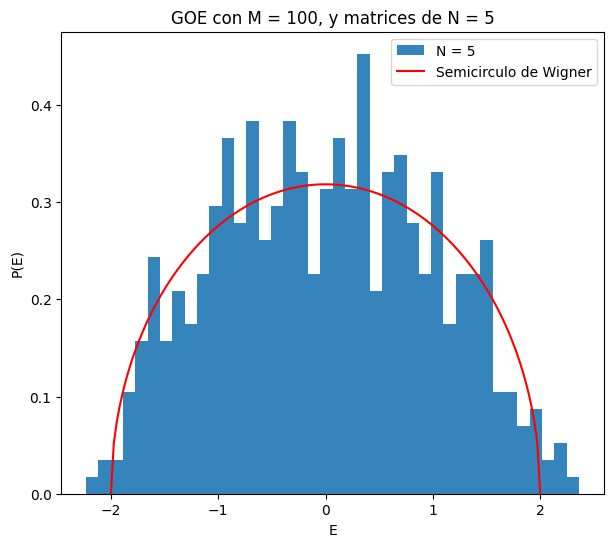

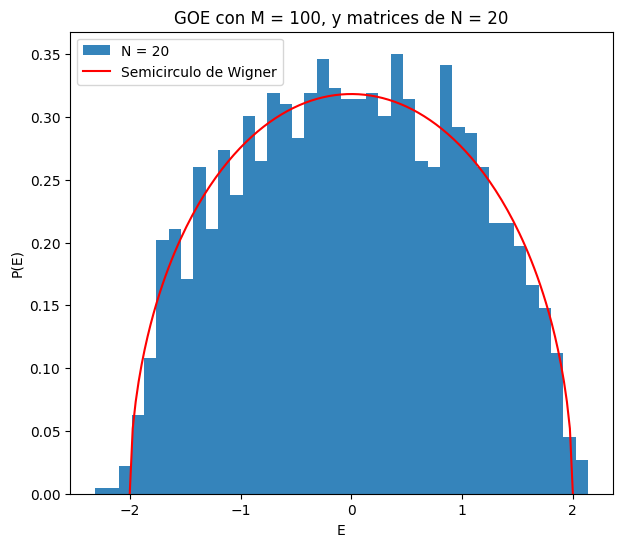

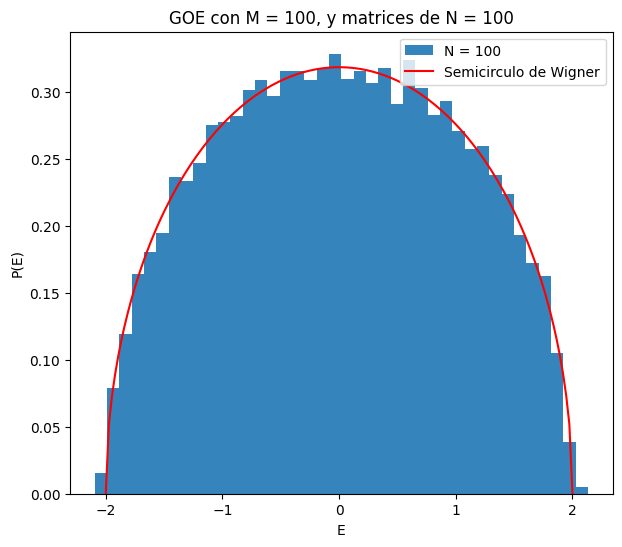

In [42]:
dimensiones = [5,20,100]
E = np.linspace(-2,2,150)
M = 100
for N in dimensiones:
    autovalores = obtención_autovalores(M,N)
    plt.figure(figsize=(7,6))
    plt.hist(autovalores, bins= 40, density=True, alpha=0.9, label=f"N = {N}")

    plt.plot(E, wigner(E), label = "Semicirculo de Wigner", color= "red")
    plt.title(f"GOE con M = {M}, y matrices de N = {N}")
    plt.xlabel("E")
    plt.ylabel("P(E)")
    plt.legend(loc="best")



# Comentario sobre la comparación
Se observa que, al aumentar la dimensión (N) de las matrices simétricas del ensamble GOE, la distribución de sus autovalores se aproxima progresivamente a la ley del semicírculo de Wigner. Para (N=5) se presentan fluctuaciones importantes y la distribución aún se aleja de la curva teórica; para (N=20) comienza a apreciarse con mayor claridad la forma semicircular; mientras que para (N=100) existe una mejor concordancia con la distribución límite.

Este comportamiento es consistente con el hecho de que la ley del semicírculo de Wigner corresponde al límite \(N\to\infty\). Por lo tanto, al incrementar (N), los efectos asociados al tamaño finito de las matrices disminuyen y la densidad de autovalores converge hacia la distribución teórica.

También se debe distinguir el efecto de (N) del efecto de (M): aumentar (M), el número de matrices del ensamble, mejora la estadística y hace más suave el histograma, mientras que aumentar (N) es lo que permite observar la convergencia hacia la distribución límite de Wigner.